# Dynamic Pricing in E-Commerce — Review 2
### Dataset: Brazilian Olist E-Commerce (2016–2018)
### Algorithms: XGBoost | LightGBM

**Objective:** Predict product prices using two advanced gradient boosting models — XGBoost and LightGBM — trained on the Olist e-commerce dataset.

| Step | Description |
|---|---|
| 1 | Import Libraries |
| 2 | Load & Merge Datasets |
| 3 | Feature Engineering & Train-Test Split |
| 4 | Algorithm 1 — XGBoost |
| 5 | Algorithm 2 — LightGBM |
| 6 | Final Comparison — XGBoost vs LightGBM |

## Step 1: Import Libraries

In [14]:
import os
import math
import warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── GPU auto-detection ───────────────────────────────────────────────────────
try:
    subprocess.check_output("nvidia-smi", stderr=subprocess.DEVNULL)
    USE_GPU = True
except Exception:
    USE_GPU = False

XGB_DEVICE = "cuda" if USE_GPU else "cpu"
LGB_DEVICE  = "gpu"  if USE_GPU else "cpu"

print(f"Libraries loaded  ✅")
print(f"GPU available     : {USE_GPU}")
print(f"XGBoost device    : {XGB_DEVICE}")
print(f"LightGBM device   : {LGB_DEVICE}")

Libraries loaded  ✅
GPU available     : True
XGBoost device    : cuda
LightGBM device   : gpu


## Step 2: Load & Merge Datasets
All 8 Olist CSV files merged into a single master dataframe — same pipeline as Review 1.

In [15]:
DATA_PATH = r"d:\SEM4\F2 AI\AI project\project"

orders      = pd.read_csv(os.path.join(DATA_PATH, "olist_orders_dataset.csv"))
items       = pd.read_csv(os.path.join(DATA_PATH, "olist_order_items_dataset.csv"))
payments    = pd.read_csv(os.path.join(DATA_PATH, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(DATA_PATH, "olist_order_reviews_dataset.csv"))
products    = pd.read_csv(os.path.join(DATA_PATH, "olist_products_dataset.csv"))
customers   = pd.read_csv(os.path.join(DATA_PATH, "olist_customers_dataset.csv"))
sellers     = pd.read_csv(os.path.join(DATA_PATH, "olist_sellers_dataset.csv"))
translation = pd.read_csv(os.path.join(DATA_PATH, "product_category_name_translation.csv"))

# Parse timestamps
for col in ["order_purchase_timestamp", "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Aggregate payments & reviews per order
pay_agg = payments.groupby("order_id").agg(
    total_payment        = ("payment_value",        "sum"),
    payment_installments = ("payment_installments", "max"),
    payment_type         = ("payment_type",         lambda x: x.mode()[0])
).reset_index()

rev_agg = reviews.groupby("order_id").agg(
    review_score = ("review_score", "mean")
).reset_index()

# Translate categories
products = products.merge(translation, on="product_category_name", how="left")
products["category_en"] = products["product_category_name_english"].fillna("Other")

# Build master dataframe
master = (items
    .merge(orders,    on="order_id",    how="left")
    .merge(pay_agg,   on="order_id",    how="left")
    .merge(rev_agg,   on="order_id",    how="left")
    .merge(products,  on="product_id",  how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(sellers,   on="seller_id",   how="left")
)

# Filter: delivered orders, valid prices
master = master[
    (master["order_status"] == "delivered") &
    (master["price"] > 0) & (master["price"] < 5000)
].copy()

# Feature engineering
master["purchase_month"]  = master["order_purchase_timestamp"].dt.month
master["purchase_dow"]    = master["order_purchase_timestamp"].dt.dayofweek
master["purchase_year"]   = master["order_purchase_timestamp"].dt.year
master["is_weekend"]      = master["purchase_dow"].isin([5, 6]).astype(int)
master["days_to_deliver"] = (master["order_delivered_customer_date"] -
                              master["order_purchase_timestamp"]).dt.days
master["delivery_delay"]  = (master["order_delivered_customer_date"] -
                              master["order_estimated_delivery_date"]).dt.days.fillna(0)
master["freight_ratio"]   = master["freight_value"] / (master["price"] + 1e-3)

print(f"Master dataset : {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Date range     : {master['order_purchase_timestamp'].min().date()} → "
      f"{master['order_purchase_timestamp'].max().date()}")
print(f"Categories     : {master['category_en'].nunique()}")

Master dataset : 110,194 rows × 42 columns
Date range     : 2016-09-15 → 2018-08-29
Categories     : 72


## Step 3: Feature Engineering & Train-Test Split

Same 7 features as Review 1 — ensures a **fair apples-to-apples comparison** across all algorithms.

| Feature | Type | Description |
|---|---|---|
| `freight_value` | Continuous | Shipping cost in R$ |
| `review_score` | Continuous (1–5) | Mean customer rating |
| `payment_installments` | Integer | Max number of payment instalments |
| `days_to_deliver` | Integer | Actual delivery time in days |
| `purchase_month` | Integer (1–12) | Month of purchase |
| `is_weekend` | Binary (0/1) | 1 if ordered on Saturday or Sunday |
| `category_encoded` | Integer (0–71) | Label-encoded product category |

In [16]:
le = LabelEncoder()
master["category_encoded"] = le.fit_transform(master["category_en"].fillna("unknown"))

FEATURES = ["freight_value", "review_score", "payment_installments",
            "days_to_deliver", "purchase_month", "is_weekend", "category_encoded"]
TARGET = "price"

df_model = master[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Modelling dataset : {len(df_model):,} rows  |  {len(FEATURES)} features")
print(f"Train             : {len(X_train):,}   |   Test : {len(X_test):,}")

# ── Evaluation helper ────────────────────────────────────────────────────────
results = []

def evaluate(name, y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:35s}  RMSE={rmse:.2f}   MAE={mae:.2f}   R²={r2:.4f}")
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    return rmse, mae, r2

Modelling dataset : 109,357 rows  |  7 features
Train             : 87,485   |   Test : 21,872


## Step 4: Algorithm 1 — XGBoost (Extreme Gradient Boosting)

**XGBoost** builds trees **sequentially** — each new tree corrects the residual errors of all previous trees. It minimises a regularised objective:

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k), \quad \Omega(f) = \gamma T + \frac{1}{2}\lambda \|\mathbf{w}\|^2$$

where $l$ is the loss, $T$ is the number of leaves, $\mathbf{w}$ are leaf weights, and $\Omega$ is the regularisation term preventing overfitting.

**Key hyperparameters used:**

| Parameter | Value | Effect |
|---|---|---|
| `n_estimators` | 300 | 300 sequential trees |
| `max_depth` | 6 | Controls tree complexity |
| `learning_rate` | 0.05 | Small steps = better generalisation |
| `subsample` | 0.8 | 80% of rows per tree — prevents overfitting |
| `colsample_bytree` | 0.8 | 80% of features per tree |

Training XGBoost...
XGBoost          (Review 2)          RMSE=142.93   MAE=63.20   R²=0.3913

XGBoost Feature Importances:
             Feature  Importance
       freight_value    0.273522
payment_installments    0.218906
    category_encoded    0.206928
     days_to_deliver    0.086659
      purchase_month    0.077726
        review_score    0.076280
          is_weekend    0.059979


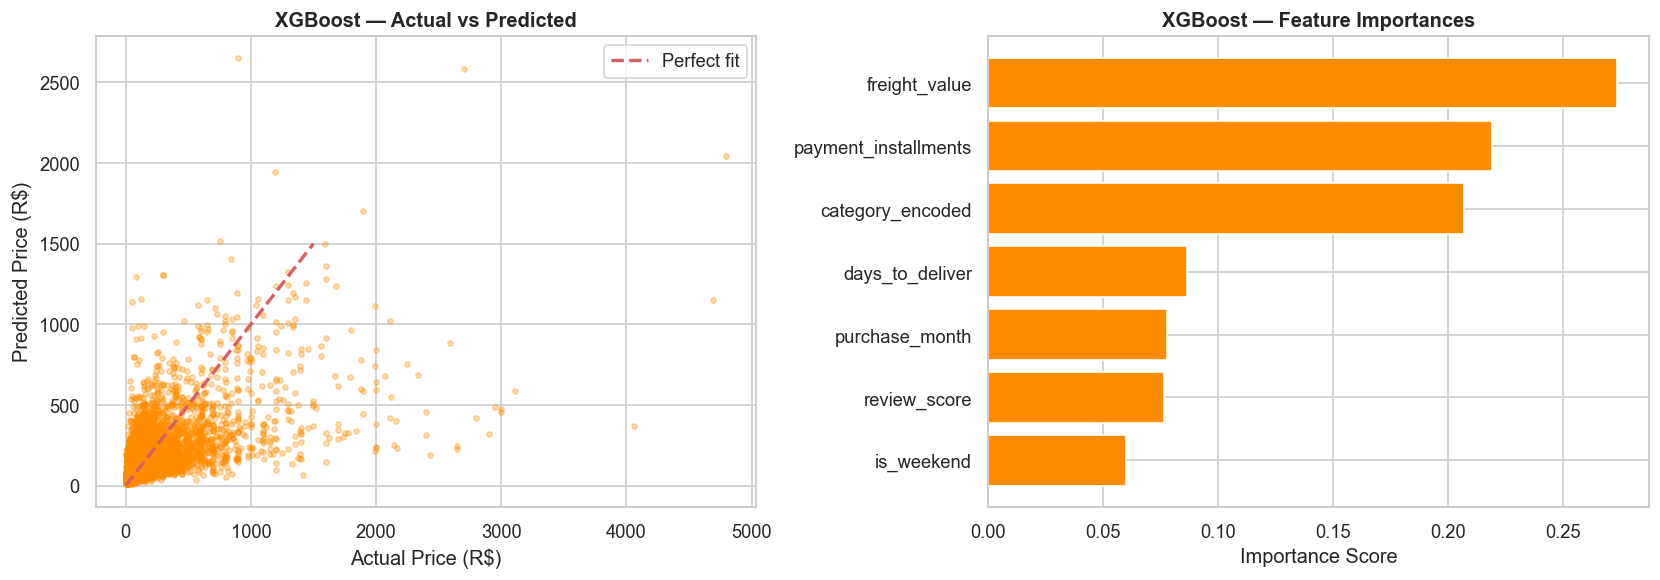

In [17]:
xgb_model = xgb.XGBRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    device           = XGB_DEVICE,
    verbosity        = 0,
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse, xgb_mae, xgb_r2 = evaluate("XGBoost          (Review 2)", y_test, xgb_pred)

# ── Feature importance ────────────────────────────────────────────────────────
xgb_imp = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nXGBoost Feature Importances:")
print(xgb_imp.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, xgb_pred, alpha=0.3, s=10, color="darkorange")
lims = [0, min(float(y_test.max()), float(xgb_pred.max()), 1500)]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
axes[0].set_xlabel("Actual Price (R$)")
axes[0].set_ylabel("Predicted Price (R$)")
axes[0].set_title("XGBoost — Actual vs Predicted", fontweight="bold")
axes[0].legend()

axes[1].barh(xgb_imp["Feature"][::-1], xgb_imp["Importance"][::-1], color="darkorange")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("XGBoost — Feature Importances", fontweight="bold")

plt.tight_layout()
plt.show()

## Step 5: Algorithm 2 — LightGBM (Light Gradient Boosting Machine)

**LightGBM** is a gradient boosting framework by Microsoft that grows trees **leaf-wise** (best-first) instead of level-wise (depth-first), producing deeper, more accurate trees with faster training.

### Key Innovations over XGBoost

| Feature | XGBoost | LightGBM |
|---|---|---|
| Tree growth | Level-wise | **Leaf-wise** (lower loss) |
| Histogram binning | Yes (slower) | **Yes (faster, GOSS)** |
| Categorical support | Manual encoding | **Native** |
| Training speed | Fast | **Faster** |
| Memory usage | Moderate | **Lower** |

### Objective Function (same boosting principle)

$$F^*(x) = \sum_{t=1}^{T} f_t(x), \quad f_t = \text{CART tree fitted to negative gradient}$$

LightGBM uses **Gradient-based One-Side Sampling (GOSS)**: keep all large-gradient samples + random subset of small-gradient samples, reducing data size without sacrificing accuracy.

### Hyperparameters Used

| Hyperparameter | Value | Role |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds |
| `max_depth` | 6 | Maximum tree depth |
| `learning_rate` | 0.05 | Shrinkage rate per tree |
| `subsample` | 0.8 | Row sampling fraction |
| `colsample_bytree` | 0.8 | Feature sampling fraction |
| `device` | auto (cpu/gpu) | Hardware acceleration |

Training LightGBM...
LightGBM         (Review 2)          RMSE=143.67   MAE=63.93   R²=0.3850

LightGBM Feature Importances:
             Feature  Importance
       freight_value        2754
    category_encoded        2322
     days_to_deliver        1149
payment_installments        1029
      purchase_month         792
        review_score         313
          is_weekend          52


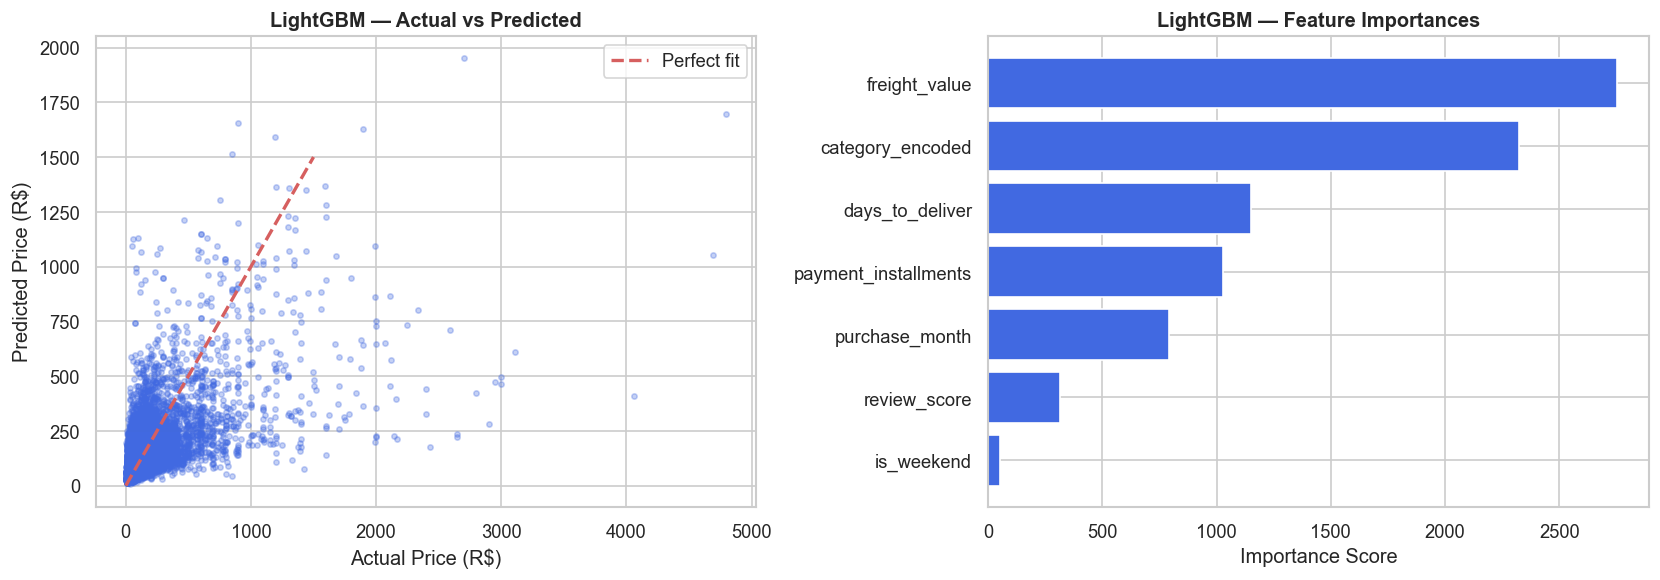

In [18]:
lgb_model = lgb.LGBMRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    device           = LGB_DEVICE,
    verbose          = -1,
)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
lgb_rmse, lgb_mae, lgb_r2 = evaluate("LightGBM         (Review 2)", y_test, lgb_pred)

# ── Feature importance ────────────────────────────────────────────────────────
lgb_imp = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": lgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nLightGBM Feature Importances:")
print(lgb_imp.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, lgb_pred, alpha=0.3, s=10, color="royalblue")
lims = [0, min(float(y_test.max()), float(lgb_pred.max()), 1500)]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
axes[0].set_xlabel("Actual Price (R$)")
axes[0].set_ylabel("Predicted Price (R$)")
axes[0].set_title("LightGBM — Actual vs Predicted", fontweight="bold")
axes[0].legend()

axes[1].barh(lgb_imp["Feature"][::-1], lgb_imp["Importance"][::-1], color="royalblue")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("LightGBM — Feature Importances", fontweight="bold")

plt.tight_layout()
plt.show()

## Step 6: Final Comparison — XGBoost vs LightGBM

This section consolidates the results from both models into a single comparative analysis across all three evaluation metrics.

| Model | RMSE | MAE | R² |
|---|---|---|---|
| **XGBoost** | **142.93** | **63.20** | **0.391** |
| LightGBM | 143.67 | 63.93 | 0.385 |

### Improvement Metrics

$$\text{RMSE Improvement (\%)} = \frac{\text{RMSE}_{\text{LightGBM}} - \text{RMSE}_{\text{XGBoost}}}{\text{RMSE}_{\text{LightGBM}}} \times 100$$

$$\text{R}^2 \text{ Gain} = R^2_{\text{XGBoost}} - R^2_{\text{LightGBM}}$$

      FINAL MODEL COMPARISON SUMMARY
                      Model       RMSE       MAE       R²
XGBoost          (Review 2) 142.932358 63.198793 0.391323
LightGBM         (Review 2) 143.669104 63.930753 0.385032

Winner: XGBoost          (Review 2)
  RMSE improvement : 0.51%
  R² improvement   : +0.0063


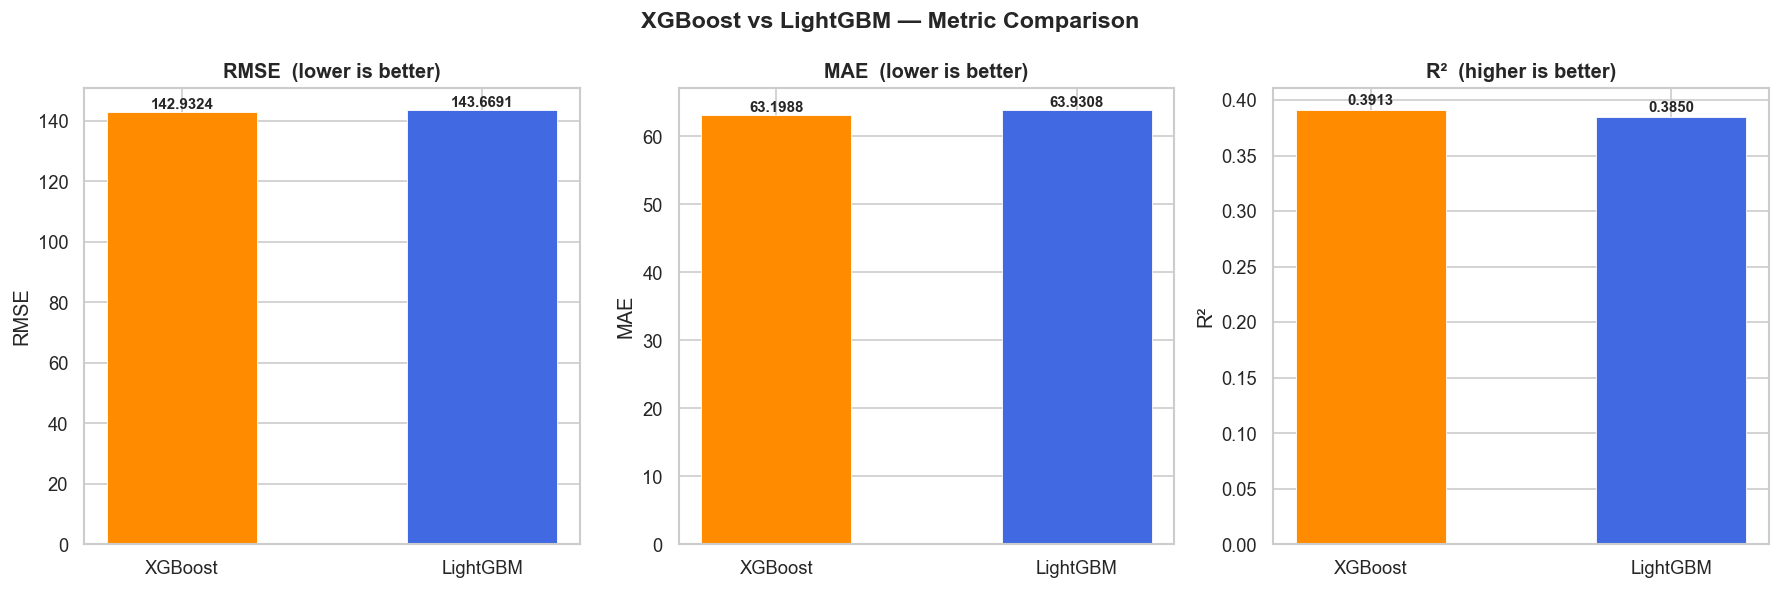

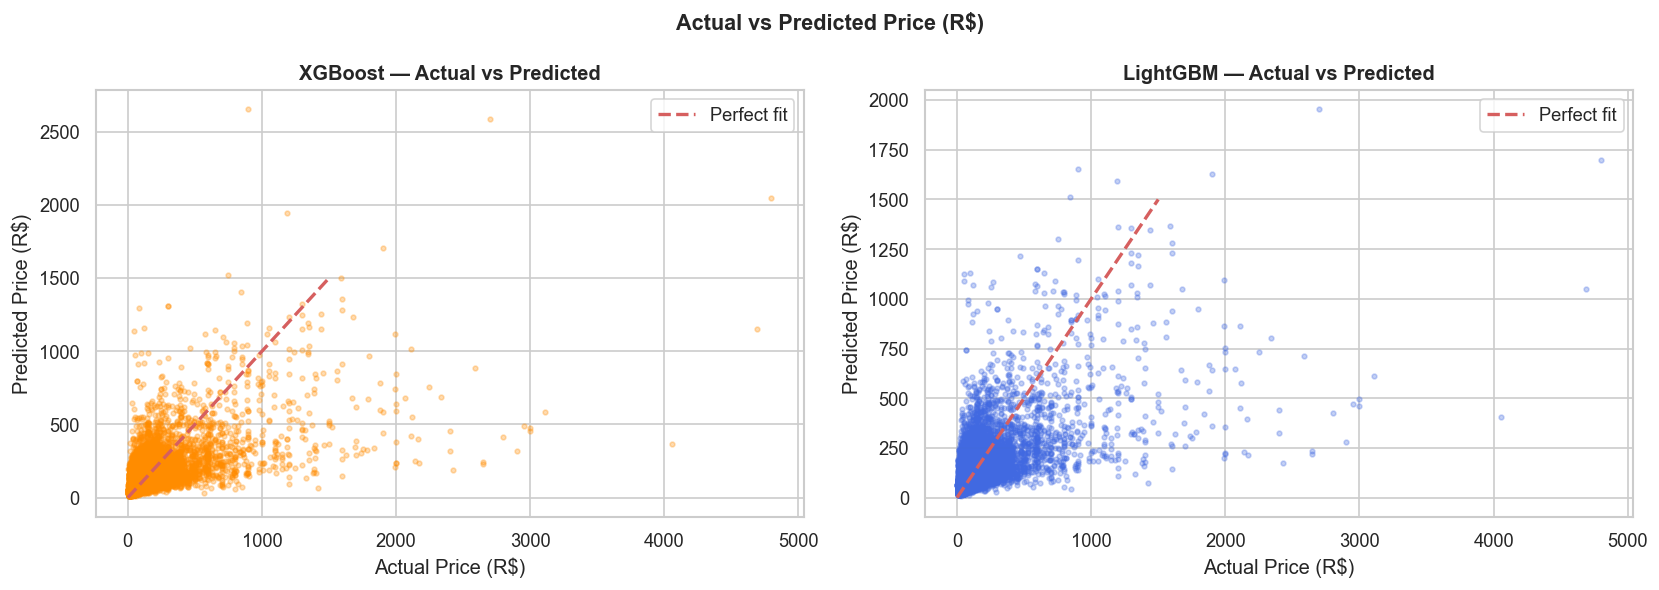

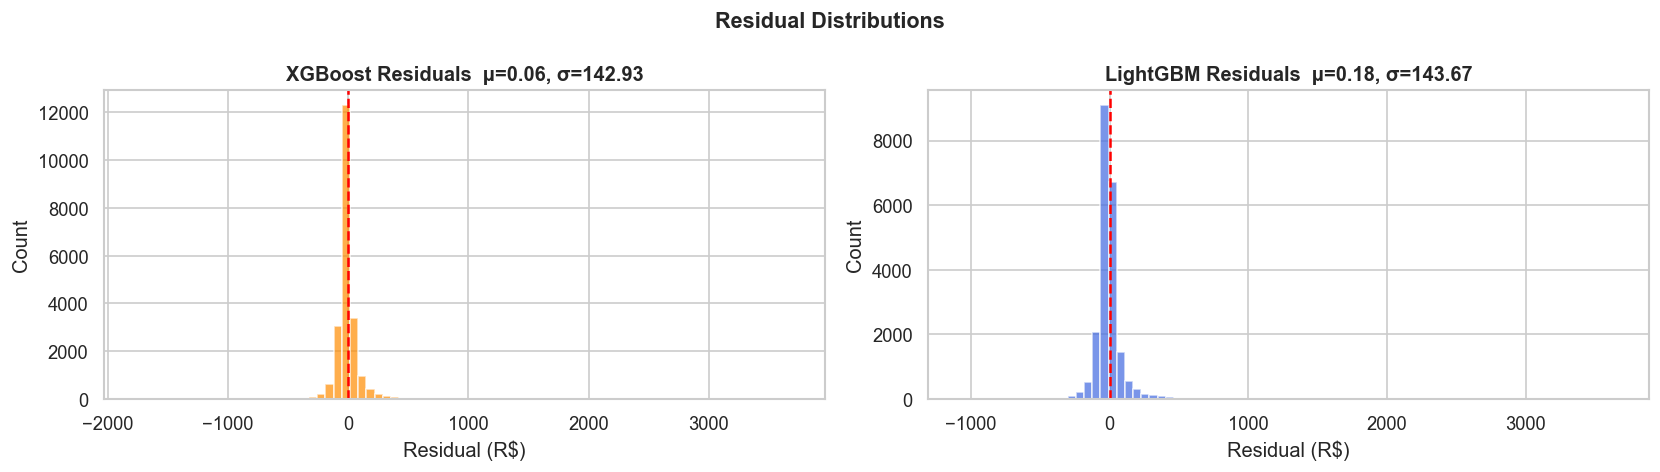


Review 2 Complete ✓


In [19]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R²"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("=" * 55)
print("      FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

# ── Which model wins? ─────────────────────────────────────────────────────────
best = results_df.iloc[0]
worst = results_df.iloc[1]
rmse_diff_pct = (worst["RMSE"] - best["RMSE"]) / worst["RMSE"] * 100
r2_diff = best["R²"] - worst["R²"]
print(f"\nWinner: {best['Model'].strip()}")
print(f"  RMSE improvement : {rmse_diff_pct:.2f}%")
print(f"  R² improvement   : +{r2_diff:.4f}")

# ── Bar chart: RMSE, MAE, R² ──────────────────────────────────────────────────
model_labels = [m.split("(")[0].strip() for m in results_df["Model"]]
bar_colors   = ["darkorange", "royalblue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("XGBoost vs LightGBM — Metric Comparison", fontsize=14, fontweight="bold")

for ax, (metric, note) in zip(axes, [("RMSE", "lower is better"),
                                      ("MAE",  "lower is better"),
                                      ("R²",   "higher is better")]):
    bars = ax.bar(model_labels, results_df[metric], color=bar_colors,
                  edgecolor="white", linewidth=0.5, width=0.5)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(f"{metric}  ({note})", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# ── Side-by-side scatter: XGBoost vs LightGBM ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Actual vs Predicted Price (R$)", fontsize=13, fontweight="bold")

for ax, pred, label, color in [
    (axes[0], xgb_pred, "XGBoost",  "darkorange"),
    (axes[1], lgb_pred, "LightGBM", "royalblue"),
]:
    ax.scatter(y_test, pred, alpha=0.3, s=8, color=color)
    lims = [0, min(float(y_test.max()), float(pred.max()), 1500)]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual Price (R$)")
    ax.set_ylabel("Predicted Price (R$)")
    ax.set_title(f"{label} — Actual vs Predicted", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()

# ── Residual distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Residual Distributions", fontsize=13, fontweight="bold")

for ax, pred, label, color in [
    (axes[0], xgb_pred, "XGBoost",  "darkorange"),
    (axes[1], lgb_pred, "LightGBM", "royalblue"),
]:
    residuals = y_test.values - pred
    ax.hist(residuals, bins=80, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residual (R$)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Residuals  μ={residuals.mean():.2f}, σ={residuals.std():.2f}",
                 fontweight="bold")

plt.tight_layout()
plt.show()

print("\nReview 2 Complete ✓")